In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import sklearn
from sklearn.preprocessing import StandardScaler

In [2]:
# Carico il dataset pinn_df
pinn_df = pd.read_csv(r"C:\Users\vinsc\Documents\Progetti\pinn_df.csv")
print(pinn_df.head())

              DateTime    House1    House2    House3    House4    House5  \
0  2023-09-18 00:00:00  0.353926  0.084078  0.303328  0.252427  0.386085   
1  2023-09-18 01:00:00  0.526320  0.057124  0.283109  0.226029  0.441071   
2  2023-09-18 02:00:00  0.536236  0.081743  0.280368  0.218727  0.484487   
3  2023-09-18 03:00:00  0.539307  0.085029  0.270917  0.206596  0.433297   
4  2023-09-18 04:00:00  0.553143  0.058800  0.265627  0.209230  0.420699   

    House11  Total_Load  Day_of_Year Day_Name  ...       SOC  Grid_Import  \
0  0.209238    1.769925          261   Monday  ...  0.500441          0.0   
1  0.176473    1.904744          261   Monday  ...  0.493281          0.0   
2  0.141122    1.941006          261   Monday  ...  0.490636          0.0   
3  0.121543    1.845225          261   Monday  ...  0.492616          0.0   
4  0.135342    1.829802          261   Monday  ...  0.496004          0.0   

   Grid_Export  Grid_Power  PV_to_Grid  Curtailment   Surplus   Deficit  \
0    

Epoch 000 | Train Loss: 2.630758 | Val Loss: 0.603266
Epoch 010 | Train Loss: 0.060209 | Val Loss: 0.051904
Epoch 020 | Train Loss: 0.039895 | Val Loss: 0.036591
Epoch 030 | Train Loss: 0.030549 | Val Loss: 0.027431
Epoch 040 | Train Loss: 0.023242 | Val Loss: 0.022735
Epoch 050 | Train Loss: 0.017111 | Val Loss: 0.016692
Epoch 060 | Train Loss: 0.013474 | Val Loss: 0.012944
Epoch 070 | Train Loss: 0.012269 | Val Loss: 0.010960
Epoch 080 | Train Loss: 0.010903 | Val Loss: 0.008521
Epoch 090 | Train Loss: 0.010048 | Val Loss: 0.016708
Epoch 100 | Train Loss: 0.008760 | Val Loss: 0.007366
Epoch 110 | Train Loss: 0.007695 | Val Loss: 0.006035
Epoch 120 | Train Loss: 0.007229 | Val Loss: 0.009133
Epoch 130 | Train Loss: 0.005973 | Val Loss: 0.005106
Epoch 140 | Train Loss: 0.006477 | Val Loss: 0.005953
Epoch 150 | Train Loss: 0.005547 | Val Loss: 0.006325
Epoch 160 | Train Loss: 0.004329 | Val Loss: 0.004997
Epoch 170 | Train Loss: 0.004457 | Val Loss: 0.005916
Epoch 180 | Train Loss: 0.00

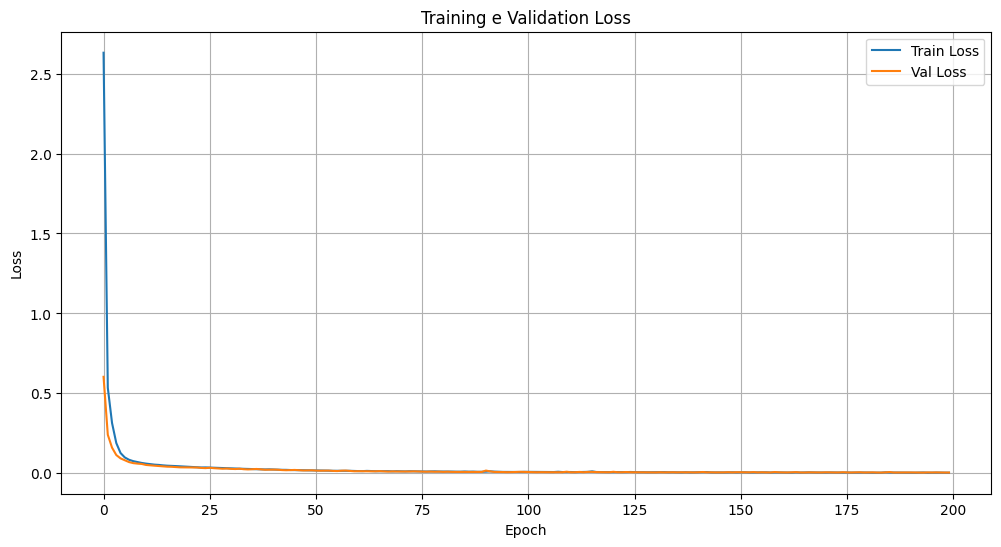


Test Loss finale: 0.014876


In [3]:
# facciamo una copia del dataset originale per non modificarlo direttamente
df = pinn_df.copy()

# convertiamo la colonna DateTime in vero formato datetime
df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")

# ordiniamo il dataset per tempo, perché la dinamica della batteria dipende dall'ordine temporale
df = df.sort_values("DateTime").reset_index(drop=True)

# ==============================
# 3) CREAZIONE DI FEATURE TEMPORALI CICLICHE
# ==============================

# estraiamo l'ora del giorno dalla colonna DateTime
df["hour"] = df["DateTime"].dt.hour

# estraiamo il giorno della settimana (0=lunedì, 6=domenica)
df["weekday"] = df["DateTime"].dt.weekday

# estraiamo il mese
df["month"] = df["DateTime"].dt.month

# trasformiamo l'ora in due variabili cicliche sin/cos
# questo evita il problema artificiale per cui 23 e 0 sembrano molto lontani
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# trasformiamo il giorno della settimana in due variabili cicliche
df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

# trasformiamo il mese in due variabili cicliche
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# ==============================
# 4) COSTRUZIONE DELLE VARIABILI "PRECEDENTI"
# ==============================

# per modellare correttamente la batteria, usiamo lo stato noto all'inizio dell'ora
# quindi prendiamo SOC e energia batteria del passo precedente
df["SOC_prev"] = df["SOC"].shift(1)

# anche l'energia in batteria del passo precedente serve per la fisica
df["Battery_Energy_prev"] = df["Battery_Energy_kWh"].shift(1)

# opzionalmente usiamo anche la batteria power del passo precedente come contesto
df["Battery_Power_prev"] = df["Battery_Power"].shift(1)

# ==============================
# 5) RIMOZIONE DELLA PRIMA RIGA
# ==============================

# la prima riga ha NaN perché non esiste un passo precedente
df = df.dropna().reset_index(drop=True)

# ==============================
# 6) SCELTA DELLE FEATURE DI INPUT
# ==============================

# queste sono le feature che diamo in ingresso alla PINN
# includiamo:
# - produzione rinnovabile
# - load totale
# - stato precedente della batteria
# - potenza precedente della batteria
# - informazioni temporali cicliche
feature_cols = [
    "Pv",
    "Total_Load",
    "SOC_prev",
    "Battery_Energy_prev",
    "Battery_Power_prev",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos"
]

# ==============================
# 7) SCELTA DEI TARGET
# ==============================

# questi sono i target che il modello deve predire
# usiamo solo i flussi principali e il SOC
target_cols = [
    "PV_to_Battery",
    "Battery_to_Load",
    "Grid_Import",
    "Grid_Export",
    "SOC"
]

# ==============================
# 8) SPLIT TEMPORALE TRAIN / VALID / TEST
# ==============================

# definiamo la lunghezza totale del dataset
n = len(df)

# usiamo uno split cronologico, non casuale, perché è una serie temporale
train_end = int(n * 0.40)
val_end = int(n * 0.55)

# train set = prima parte della serie temporale
train_df = df.iloc[:train_end].copy()

# validation set = parte centrale
val_df = df.iloc[train_end:val_end].copy()

# test set = parte finale
test_df = df.iloc[val_end:].copy()

# ==============================
# 9) NORMALIZZAZIONE DELLE FEATURE
# ==============================

# creiamo uno scaler
scaler = StandardScaler()

# lo fitto solo sui dati di train per evitare leakage
scaler.fit(train_df[feature_cols])

# trasformo train, validation e test
X_train = scaler.transform(train_df[feature_cols])
X_val = scaler.transform(val_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

# target di train/val/test
y_train = train_df[target_cols].values
y_val = val_df[target_cols].values
y_test = test_df[target_cols].values

# salviamo anche alcune colonne fisiche non normalizzate, utili per la loss fisica
phys_train = train_df[["Pv", "Total_Load", "SOC_prev", "Battery_Energy_prev"]].values
phys_val = val_df[["Pv", "Total_Load", "SOC_prev", "Battery_Energy_prev"]].values
phys_test = test_df[["Pv", "Total_Load", "SOC_prev", "Battery_Energy_prev"]].values

# ==============================
# 10) CREAZIONE DEL DATASET PYTORCH
# ==============================

# definiamo una classe custom Dataset
class MicrogridDataset(Dataset):
    
    # il costruttore riceve input, target e variabili fisiche
    def __init__(self, X, y, phys):
        
        # convertiamo gli input in tensori float32
        self.X = torch.tensor(X, dtype=torch.float32)
        
        # convertiamo i target in tensori float32
        self.y = torch.tensor(y, dtype=torch.float32)
        
        # convertiamo anche le variabili fisiche in tensori float32
        self.phys = torch.tensor(phys, dtype=torch.float32)

    # questo metodo restituisce il numero di campioni
    def __len__(self):
        return len(self.X)

    # questo metodo restituisce un singolo campione
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.phys[idx]

# creiamo i dataset PyTorch
train_dataset = MicrogridDataset(X_train, y_train, phys_train)
val_dataset = MicrogridDataset(X_val, y_val, phys_val)
test_dataset = MicrogridDataset(X_test, y_test, phys_test)

# ==============================
# 11) CREAZIONE DEI DATALOADER
# ==============================

# il DataLoader spezza i dati in batch e li mescola in training
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# validation loader senza shuffle
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# test loader senza shuffle
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# ==============================
# 12) PARAMETRI FISICI DELLA BATTERIA
# ==============================

# capacità nominale della batteria in kWh
E_max = 80.0

# efficienza di carica
eta_ch = 0.95

# efficienza di scarica
eta_dis = 0.95

# limiti min e max del SOC
SOC_min = 0.10
SOC_max = 0.90

# energia minima utilizzabile
E_min = SOC_min * E_max

# energia massima utilizzabile
E_max_use = SOC_max * E_max

# ==============================
# 13) DEFINIZIONE DELLA RETE NEURALE
# ==============================

# definiamo una rete semplice fully-connected
class PINNMicrogrid(nn.Module):
    
    # costruttore della rete
    def __init__(self, input_dim):
        
        # inizializziamo la classe base
        super().__init__()
        
        # definiamo il backbone della rete
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, 64),   # primo layer lineare: input -> 64 neuroni
            nn.ReLU(),                  # attivazione non lineare
            nn.Linear(64, 64),          # secondo layer nascosto
            nn.ReLU(),                  # attivazione
            nn.Linear(64, 64),          # terzo layer nascosto
            nn.ReLU()                   # attivazione
        )
        
        # testa finale che produce 5 output grezzi
        self.head = nn.Linear(64, 5)

    # forward pass
    def forward(self, x):
        
        # passiamo x nel backbone
        h = self.backbone(x)
        
        # otteniamo output grezzi
        out = self.head(h)
        
        # separiamo gli output
        raw_pv_to_battery = out[:, 0:1]   # output grezzo per PV_to_Battery
        raw_battery_to_load = out[:, 1:2] # output grezzo per Battery_to_Load
        raw_grid_import = out[:, 2:3]     # output grezzo per Grid_Import
        raw_grid_export = out[:, 3:4]     # output grezzo per Grid_Export
        raw_soc = out[:, 4:5]             # output grezzo per SOC
        
        # usiamo Softplus per rendere i flussi non negativi
        # Softplus è una versione liscia di ReLU ed è utile nelle PINN
        pv_to_battery = torch.nn.functional.softplus(raw_pv_to_battery)
        battery_to_load = torch.nn.functional.softplus(raw_battery_to_load)
        grid_import = torch.nn.functional.softplus(raw_grid_import)
        grid_export = torch.nn.functional.softplus(raw_grid_export)
        
        # usiamo una sigmoid per vincolare SOC tra SOC_min e SOC_max
        soc = SOC_min + (SOC_max - SOC_min) * torch.sigmoid(raw_soc)
        
        # concateniamo tutto in un unico tensore di output
        return torch.cat(
            [pv_to_battery, battery_to_load, grid_import, grid_export, soc],
            dim=1
        )

# creiamo il modello
model = PINNMicrogrid(input_dim=len(feature_cols))

# ==============================
# 14) OTTIMIZZATORE
# ==============================

# Adam è una scelta molto comune per iniziare
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ==============================
# 15) LOSS DATA-DRIVEN
# ==============================

# useremo MSE sui target osservati
mse_loss = nn.MSELoss()

# ==============================
# 16) FUNZIONE DI LOSS PHYSICS-INFORMED
# ==============================

# questa funzione combina:
# - loss sui dati
# - loss fisica sul bilancio energetico
# - loss fisica sulla dinamica batteria
# - penalità su carica/scarica simultanee
# - penalità su import/export simultanei
def pinn_loss(y_pred, y_true, phys):
    
    # estraiamo gli output predetti
    pv_to_battery_pred = y_pred[:, 0]
    battery_to_load_pred = y_pred[:, 1]
    grid_import_pred = y_pred[:, 2]
    grid_export_pred = y_pred[:, 3]
    soc_pred = y_pred[:, 4]
    
    # estraiamo i target veri
    pv_to_battery_true = y_true[:, 0]
    battery_to_load_true = y_true[:, 1]
    grid_import_true = y_true[:, 2]
    grid_export_true = y_true[:, 3]
    soc_true = y_true[:, 4]
    
    # estraiamo le variabili fisiche note
    pv_now = phys[:, 0]
    load_now = phys[:, 1]
    soc_prev = phys[:, 2]
    energy_prev = phys[:, 3]
    
    # ------------------------------
    # LOSS SUI DATI
    # ------------------------------
    
    # errore quadratico medio sugli output osservati
    loss_data = mse_loss(y_pred, y_true)
    
    # ------------------------------
    # LOSS 1: BILANCIO ENERGETICO
    # ------------------------------
    
    # lato sinistro del bilancio energetico
    lhs_energy = pv_now + grid_import_pred + battery_to_load_pred
    
    # lato destro del bilancio energetico
    rhs_energy = load_now + pv_to_battery_pred + grid_export_pred
    
    # residuo fisico del bilancio energetico
    loss_energy = torch.mean((lhs_energy - rhs_energy) ** 2)
    
    # ------------------------------
    # LOSS 2: DINAMICA DELLA BATTERIA
    # ------------------------------
    
    # energia "raw" prevista dalla fisica della batteria
    energy_next_raw = (
        energy_prev
        + eta_ch * pv_to_battery_pred
        - battery_to_load_pred / eta_dis
    )
    
    # applichiamo i limiti fisici della batteria
    energy_next_clamped = torch.clamp(energy_next_raw, min=E_min, max=E_max_use)
    
    # convertiamo l'energia prevista in SOC previsto dalla fisica
    soc_from_physics = energy_next_clamped / E_max
    
    # imponiamo coerenza tra SOC predetto dalla rete e SOC fisico
    loss_battery = torch.mean((soc_pred - soc_from_physics) ** 2)
    
    # ------------------------------
    # LOSS 3: NIENTE CARICA/SCARICA SIMULTANEE
    # ------------------------------
    
    # se entrambi sono positivi contemporaneamente, il prodotto cresce
    # quindi la rete viene penalizzata
    loss_no_simul_battery = torch.mean((pv_to_battery_pred * battery_to_load_pred) ** 2)
    
    # ------------------------------
    # LOSS 4: NIENTE IMPORT/EXPORT SIMULTANEI
    # ------------------------------
    
    # stessa logica per import ed export
    loss_no_simul_grid = torch.mean((grid_import_pred * grid_export_pred) ** 2)
    
    # ------------------------------
    # COMBINAZIONE DELLE LOSS
    # ------------------------------
    
    # peso della loss sui dati
    lambda_data = 1.0
    
    # peso del bilancio energetico
    lambda_energy = 1.0
    
    # peso della dinamica batteria
    lambda_battery = 1.0
    
    # peso del vincolo no carica/scarica simultanee
    lambda_no_batt = 0.1
    
    # peso del vincolo no import/export simultanei
    lambda_no_grid = 0.1
    
    # loss totale
    total_loss = (
        lambda_data * loss_data
        + lambda_energy * loss_energy
        + lambda_battery * loss_battery
        + lambda_no_batt * loss_no_simul_battery
        + lambda_no_grid * loss_no_simul_grid
    )
    
    # restituiamo sia la loss totale sia i dettagli
    return total_loss, {
        "loss_data": loss_data.item(),
        "loss_energy": loss_energy.item(),
        "loss_battery": loss_battery.item(),
        "loss_no_simul_battery": loss_no_simul_battery.item(),
        "loss_no_simul_grid": loss_no_simul_grid.item()
    }

# ==============================
# 17) FUNZIONE DI VALIDAZIONE
# ==============================

# questa funzione valuta il modello sul validation set
def evaluate(model, loader):
    
    # mettiamo il modello in modalità evaluation
    model.eval()
    
    # lista per salvare le loss dei batch
    losses = []
    
    # disabilitiamo il calcolo dei gradienti
    with torch.no_grad():
        
        # scorriamo i batch
        for X_batch, y_batch, phys_batch in loader:
            
            # predizione del modello
            y_pred = model(X_batch)
            
            # calcolo della loss
            loss, _ = pinn_loss(y_pred, y_batch, phys_batch)
            
            # salviamo la loss
            losses.append(loss.item())
    
    # ritorniamo la loss media
    return np.mean(losses)

# ==============================
# 18) TRAINING LOOP
# ==============================

# numero di epoche
num_epochs = 200

# liste per tenere traccia delle loss
train_losses = []
val_losses = []

# loop sulle epoche
for epoch in range(num_epochs):
    
    # mettiamo il modello in modalità training
    model.train()
    
    # lista delle loss di questa epoca
    epoch_losses = []
    
    # scorriamo i batch del training
    for X_batch, y_batch, phys_batch in train_loader:
        
        # azzeriamo i gradienti del passo precedente
        optimizer.zero_grad()
        
        # forward pass
        y_pred = model(X_batch)
        
        # calcolo della loss totale
        loss, loss_dict = pinn_loss(y_pred, y_batch, phys_batch)
        
        # backward pass
        loss.backward()
        
        # aggiornamento dei pesi
        optimizer.step()
        
        # salviamo la loss del batch
        epoch_losses.append(loss.item())
    
    # loss media di training
    train_loss = np.mean(epoch_losses)
    
    # loss di validation
    val_loss = evaluate(model, val_loader)
    
    # salviamo le loss
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # stampiamo ogni 10 epoche
    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )

# Grafico delle loss di training e validation
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training e Validation Loss")
plt.legend()
plt.grid()
plt.show()

# ==============================
# 19) VALUTAZIONE FINALE SU TEST
# ==============================

# valutiamo sul test set
test_loss = evaluate(model, test_loader)

# stampiamo il risultato finale
print(f"\nTest Loss finale: {test_loss:.6f}")

# ==============================
# 20) PREDIZIONI SU TEST SET
# ==============================

# mettiamo il modello in evaluation
model.eval()

# lista per raccogliere le predizioni
pred_list = []

# niente gradienti
with torch.no_grad():
    
    # scorriamo il test set
    for X_batch, y_batch, phys_batch in test_loader:
        
        # predizione
        y_pred = model(X_batch)
        
        # convertiamo in numpy e salviamo
        pred_list.append(y_pred.numpy())

# concateniamo tutte le predizioni
pred_array = np.vstack(pred_list)

# costruiamo un dataframe con le predizioni
pred_df = test_df[["DateTime"]].copy()

# assegniamo le colonne predette
pred_df["PV_to_Battery_pred"] = pred_array[:, 0]
pred_df["Battery_to_Load_pred"] = pred_array[:, 1]
pred_df["Grid_Import_pred"] = pred_array[:, 2]
pred_df["Grid_Export_pred"] = pred_array[:, 3]
pred_df["SOC_pred"] = pred_array[:, 4]

# aggiungiamo anche i valori reali per confronto
pred_df["PV_to_Battery_true"] = test_df["PV_to_Battery"].values
pred_df["Battery_to_Load_true"] = test_df["Battery_to_Load"].values
pred_df["Grid_Import_true"] = test_df["Grid_Import"].values
pred_df["Grid_Export_true"] = test_df["Grid_Export"].values
pred_df["SOC_true"] = test_df["SOC"].values

# stampiamo le prime righe
#print(pred_df.head())

===== METRICHE SOC =====
MAE  = 0.006929
RMSE = 0.013665
R²   = 0.996996
MAPE = 2.27%


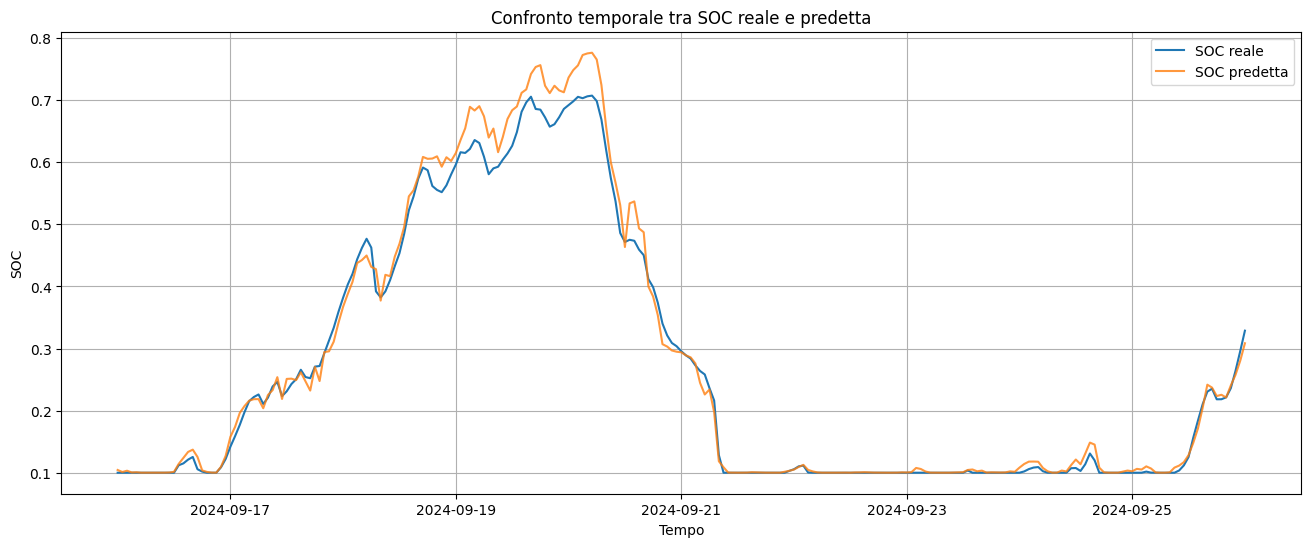

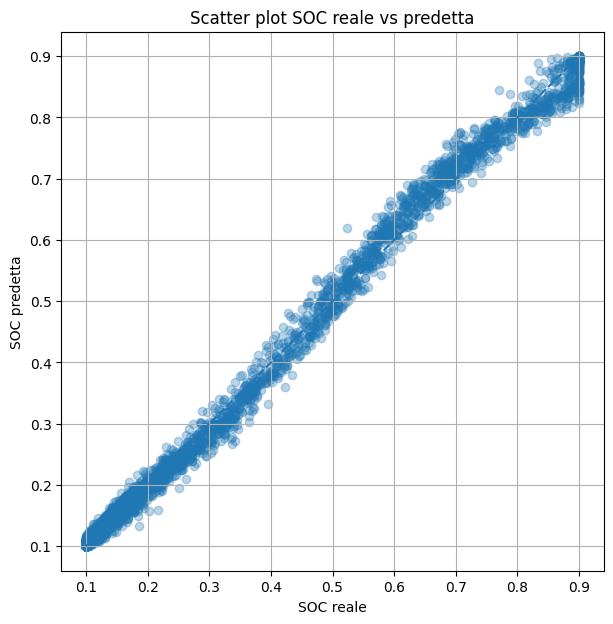

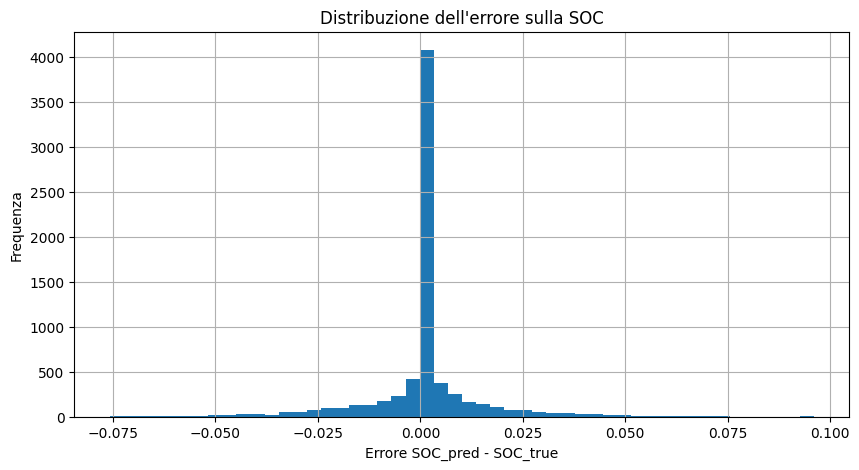

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# copia del dataframe predizioni
soc_df = pred_df.copy()

# assicuriamoci che DateTime sia datetime
soc_df["DateTime"] = pd.to_datetime(soc_df["DateTime"])

# ordiniamo per tempo
soc_df = soc_df.sort_values("DateTime")

# =========================
# 1) METRICHE NUMERICHE
# =========================

y_true = soc_df["SOC_true"].values
y_pred = soc_df["SOC_pred"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


print("===== METRICHE SOC =====")
print(f"MAE  = {mae:.6f}")
print(f"RMSE = {rmse:.6f}")
print(f"R²   = {r2:.6f}")
print(f"MAPE = {mape:.2f}%")

# =========================
# 2) GRAFICO TEMPORALE
# =========================

# scegli una finestra di visualizzazione
start = soc_df["DateTime"].iloc[0]
end = start + pd.Timedelta(days=10)

plot_df = soc_df[(soc_df["DateTime"] >= start) & (soc_df["DateTime"] <= end)]

plt.figure(figsize=(16, 6))
plt.plot(plot_df["DateTime"], plot_df["SOC_true"], label="SOC reale")
plt.plot(plot_df["DateTime"], plot_df["SOC_pred"], label="SOC predetta", alpha=0.8)
plt.xlabel("Tempo")
plt.ylabel("SOC")
plt.title("Confronto temporale tra SOC reale e predetta")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 3) SCATTER PLOT TRUE vs PRED
# =========================

plt.figure(figsize=(7, 7))
plt.scatter(soc_df["SOC_true"], soc_df["SOC_pred"], alpha=0.3)

mn = min(soc_df["SOC_true"].min(), soc_df["SOC_pred"].min())
mx = max(soc_df["SOC_true"].max(), soc_df["SOC_pred"].max())

plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("SOC reale")
plt.ylabel("SOC predetta")
plt.title("Scatter plot SOC reale vs predetta")
plt.grid(True)
plt.show()

# =========================
# 4) ISTOGRAMMA DELL'ERRORE
# =========================

soc_df["SOC_error"] = soc_df["SOC_pred"] - soc_df["SOC_true"]

plt.figure(figsize=(10, 5))
plt.hist(soc_df["SOC_error"], bins=50)
plt.xlabel("Errore SOC_pred - SOC_true")
plt.ylabel("Frequenza")
plt.title("Distribuzione dell'errore sulla SOC")
plt.grid(True)
plt.show()